In [34]:
import pandas as pd
import numpy as np
import seaborn as sns
from plotnine import *

titanic = sns.load_dataset('titanic')

-----

# Dtypes

In [10]:
users_dt = pd.read_csv('../Datasets/Exercise2_datasets/BX-Users.csv')
users_dt.dtypes

User-ID       int64
Location     object
Age         float64
dtype: object

-------

# How To Filter

use `.loc` instead of `titanic[~ind, 'age']`

In [4]:
ind = np.isnan(titanic['age'])
titanic.loc[~ind, 'age'].values.mean()

np.float64(29.69911764705882)

In [39]:
books_dt = pd.read_csv('../Datasets/Exercise2_datasets/BX-Books.csv') 
books_dt = books_dt.drop(columns = ['Image-URL-S', 'Image-URL-M', 'Image-URL-L']) # önemsiz

book_df_2 = books_dt[books_dt['Year-Of-Publication'].isin(range(1900,2020))]
book_df_2.head()

books_dt[books_dt['Year-Of-Publication'].isin(range(1900,2020))][['ISBN','Book-Title']]

,ISBN,Book-Title
0,0195153448,Classical Mythology
1,0002005018,Clara Callan
2,0060973129,Decision in Normandy
3,0374157065,Flu: The Story of the Great Influenza Pandemic...
4,0393045218,The Mummies of Urumchi
...,...,...
262495,0441297528,The Golden Naginata
262496,0441792642,Sensei II: Sword Master
262497,0448164884,More Stan Fishchler's Sports Stumpers
262498,0451520521,Babbitt


----

# idxmin - Argmin

In [5]:
tips = sns.load_dataset('tips')
tips['total_bill'].idxmin()

67

------

# Categories

* `nunique()` → how many values actually appear

* `dtype.categories` → how many values are allowed by the type

<u>return_counts = True</u>

In [84]:
b = tips['day']
unique_values, counts = np.unique(b, return_counts= True)

print('Values:', unique_values)
print('Counts:', counts)

b.dtype.categories

Values: ['Fri' 'Sat' 'Sun' 'Thur']
Counts: [19 87 76 62]


Index(['Thur', 'Fri', 'Sat', 'Sun'], dtype='object')

-------

# Drop 

## Column

In [16]:
books_dt = pd.read_csv('../Datasets/Exercise2_datasets/BX-Books.csv')

books_dt = books_dt.drop(columns = ['Image-URL-S', 'Image-URL-M', 'Image-URL-L'])

## NA

In [42]:
np.random.seed(0)

df = pd.DataFrame({
    'age': [23, np.nan, 35, np.nan, 42],
    'fare': [100, 200, np.nan, 150, np.nan],
    'sex': ['male', 'female', 'female', 'male', 'female']
})

df.head()

,age,fare,sex
0,23.0,100.0,male
1,NaN,200.0,female
2,35.0,NaN,female
3,NaN,150.0,male
4,42.0,NaN,female


In [ ]:
df.dropna(subset = ['fare', 'age'], how = 'all') # any

,age,fare,sex
0,23.0,100.0,male
1,NaN,200.0,female
2,35.0,NaN,female
3,NaN,150.0,male
4,42.0,NaN,female


how = 'all' makes sure that only rows are dropped where both, fare and age are none

------

# Unique

In [21]:
books_dt = pd.read_csv('../Datasets/Exercise2_datasets/BX-Books.csv')

books_dt['Book-Author'].nunique()

98538

In [25]:
tips = sns.load_dataset('tips')

b = tips['time']
unique_values, counts = np.unique(b, return_counts= True)

print('Values:', unique_values)
print('Counts:', counts)

Values: ['Dinner' 'Lunch']
Counts: [176  68]


---------

# Common - mode

the most common rating value larger than 0

In [22]:
ratings_dt = pd.read_csv('../Datasets/Exercise2_datasets/BX-Book-Ratings.csv')

ratings_dt[ ratings_dt['Book-Rating'] != 0]['Book-Rating'].mode()

0    8
Name: Book-Rating, dtype: int64

-----

# Size 

size()

In [ ]:
star_wars_df = pd.read_csv('../Datasets/Exercise2_datasets/star_wars_character_dataset.csv',
                    usecols = ["name", "height", "mass", "birth_year", "sex", "homeworld", "species"])

star_wars_df = star_wars_df.rename(columns = {'birth_year': 'age'})

star_wars_df[star_wars_df['height'] > 200].groupby('species').size()

species
Gungan      2
Human       1
Kaleesh     1
Kaminoan    2
Pau'an      1
Quermian    1
Wookiee     2
dtype: int64

size

In [26]:
tips = sns.load_dataset('tips')

tips.size

1708

-------------

# Rename Column

In [27]:
star_wars_df = pd.read_csv('../Datasets/Exercise2_datasets/star_wars_character_dataset.csv',
                    usecols = ["name", "height", "mass", "birth_year", "sex", "homeworld", "species"])

star_wars_df = star_wars_df.rename(columns = {'birth_year': 'age'})
star_wars_df.head()

,name,height,mass,age,sex,homeworld,species
0,Luke Skywalker,172.0,77.0,19.0,male,Tatooine,Human
1,C-3PO,167.0,75.0,112.0,none,Tatooine,Droid
2,R2-D2,96.0,32.0,33.0,none,Naboo,Droid
3,Darth Vader,202.0,136.0,41.9,male,Tatooine,Human
4,Leia Organa,150.0,49.0,19.0,female,Alderaan,Human


---------

# np.where()

In [67]:
np.random.seed(123)
random_number = np.random.normal(loc = 0, scale = 10, size = 100)

whereDf = pd.DataFrame({'nums':random_number})

whereDf['greaterThan0'] = np.where(whereDf['nums'] > 0, 1,0)
whereDf.head()


,nums,greaterThan0
0,-10.856306,0
1,9.973454,1
2,2.829785,1
3,-15.062947,0
4,-5.786003,0


------

# Transform

/var/folders/nn/rd9y9hfx7qz4tk9cjwqs2xrh0000gn/T/ipykernel_92911/873672501.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


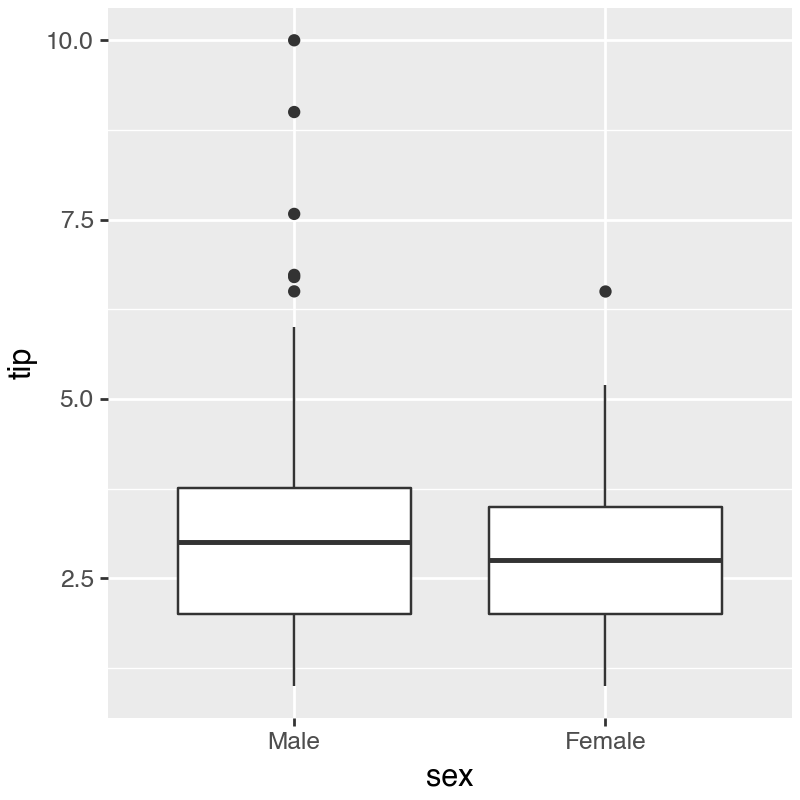

In [36]:
dt = sns.load_dataset('tips')
dt['sex_av'] = dt.groupby('sex')['tip'].transform('mean')

dt['dist_avg'] = dt['tip'] - dt['sex_av']

(
    ggplot(dt, aes('sex', 'tip')) + 
    geom_boxplot() +
    theme(figure_size= (4,4))
)

--------

# Union

concat 

In [45]:
import glob

files = glob.glob('../Datasets/Exercise2_datasets/extdata 3/baby-names/*.csv')

dfs = []

for i in range(len(files)):
    df = pd.read_csv(files[i])
    df['year'] = files[i].split('/')[-1].split('.')[0]
    dfs.append(df)

df = pd.concat(dfs, ignore_index= True)  ## Important part
df.head()

,name,percent,year
0,Jacob,0.016514,2000
1,Michael,0.015346,2000
2,Matthew,0.013695,2000
3,Joshua,0.013194,2000
4,Christopher,0.011990,2000


-------

# Draw Line

## stat_smooth(method = 'lm')

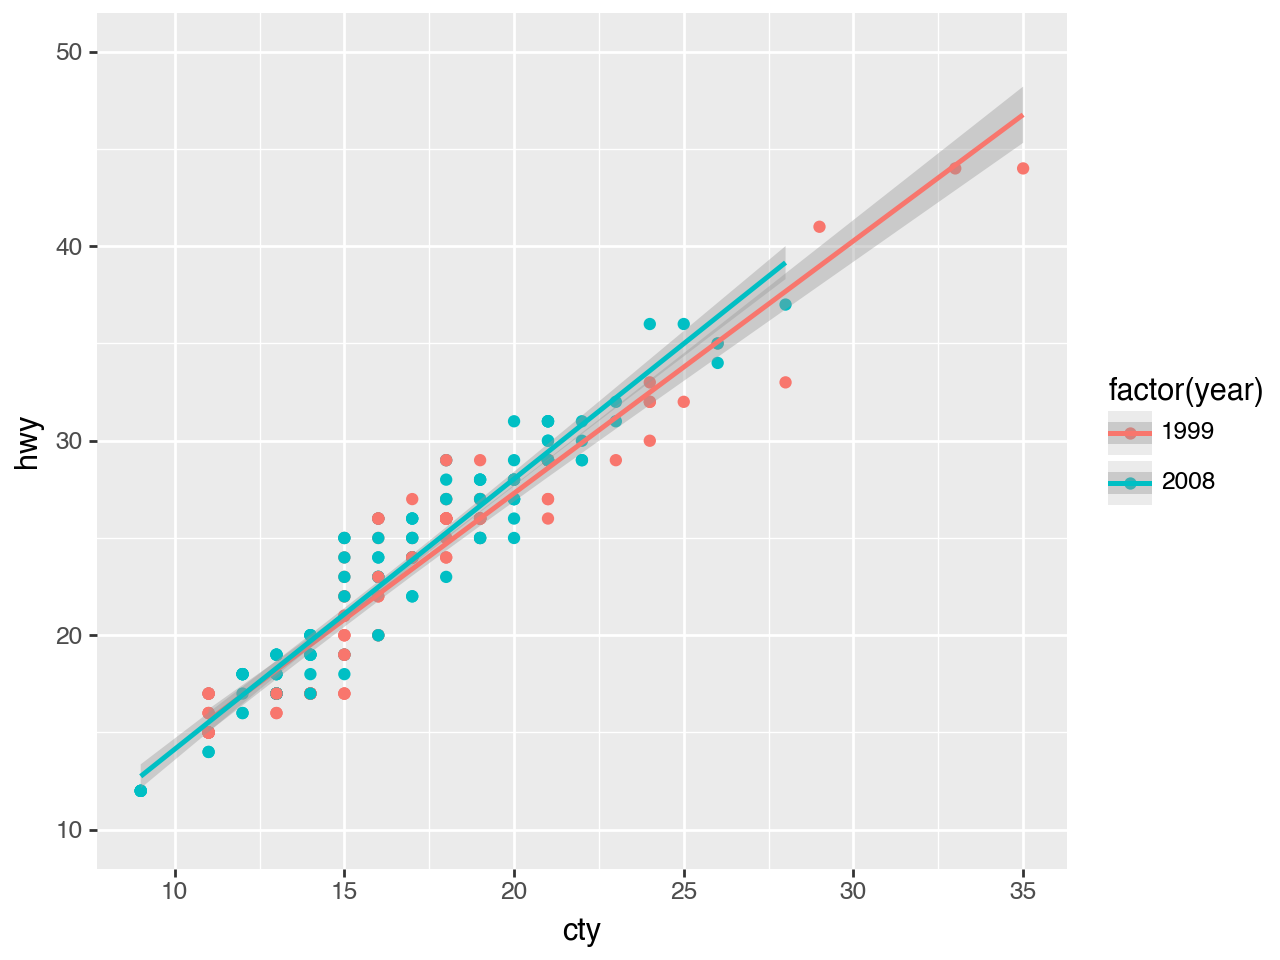

In [48]:
from plotnine.data import mpg

df = mpg[mpg['year'].isin([1999, 2008])][['cty','hwy', 'year']]
df['year'] = df['year'].astype('category')

(
    ggplot(df, aes(x = 'cty', y = 'hwy', color = 'year')) +
    geom_point() +
    stat_smooth(method = 'lm') +
    scale_y_continuous(limits=(10, 50)) + 
    labs(color = 'factor(year)')
)


## geom_jitter()

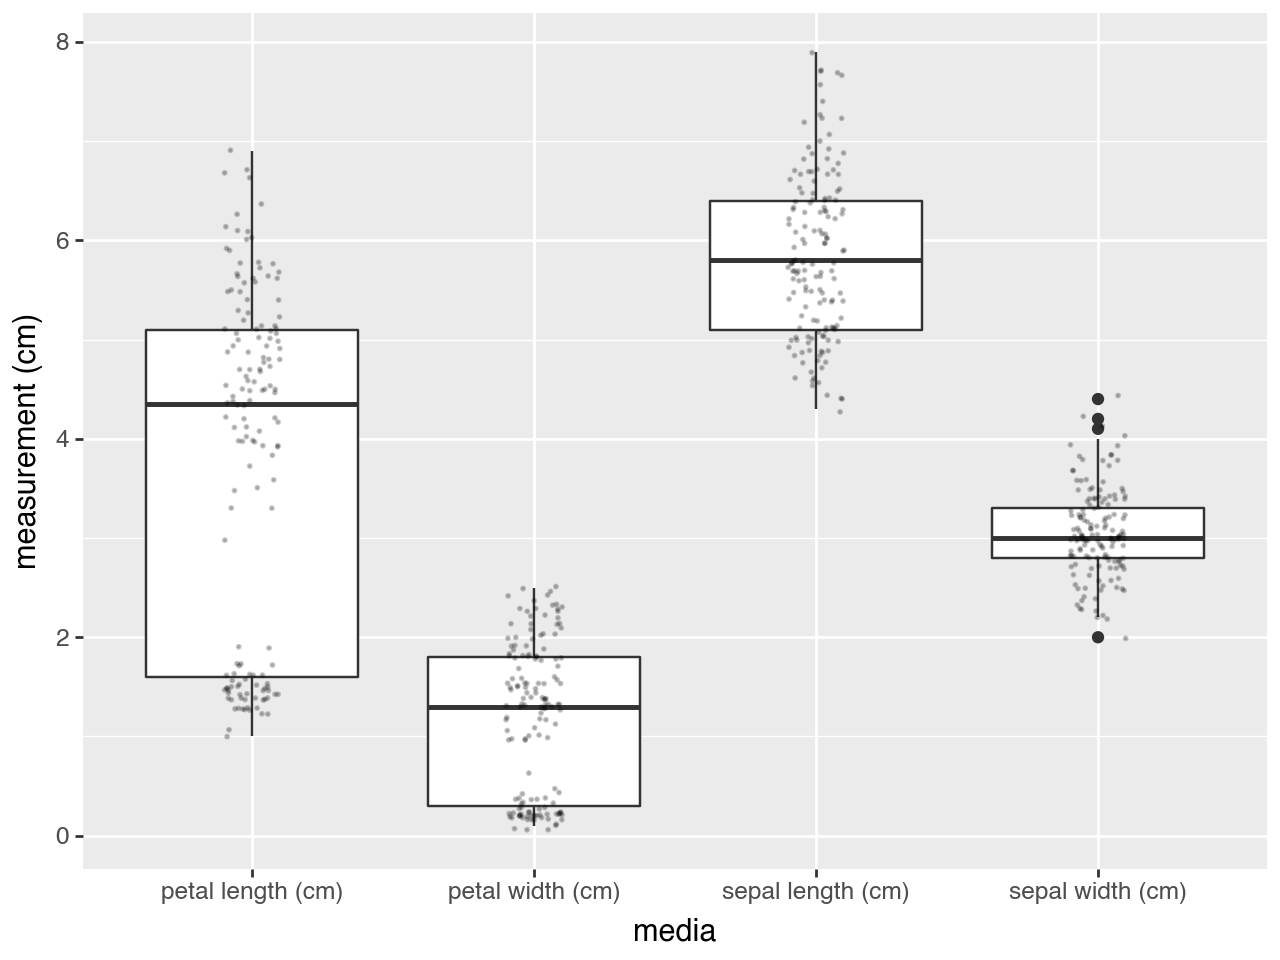

In [50]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)['frame']

iris['target'] = ['setosa' if s==0 else 'versicolor' if s==1 else 'virginica' \
for s in iris['target']]

iris_dist = iris.melt(id_vars= 'target', var_name= 'media', value_name= 'measurement (cm)')

(
    ggplot(iris_dist, aes(x = 'media', y = 'measurement (cm)'))+
    geom_boxplot() + 
    geom_jitter(width = 0.1, size = 0.2, alpha = 0.2)
)

## geom_violin()

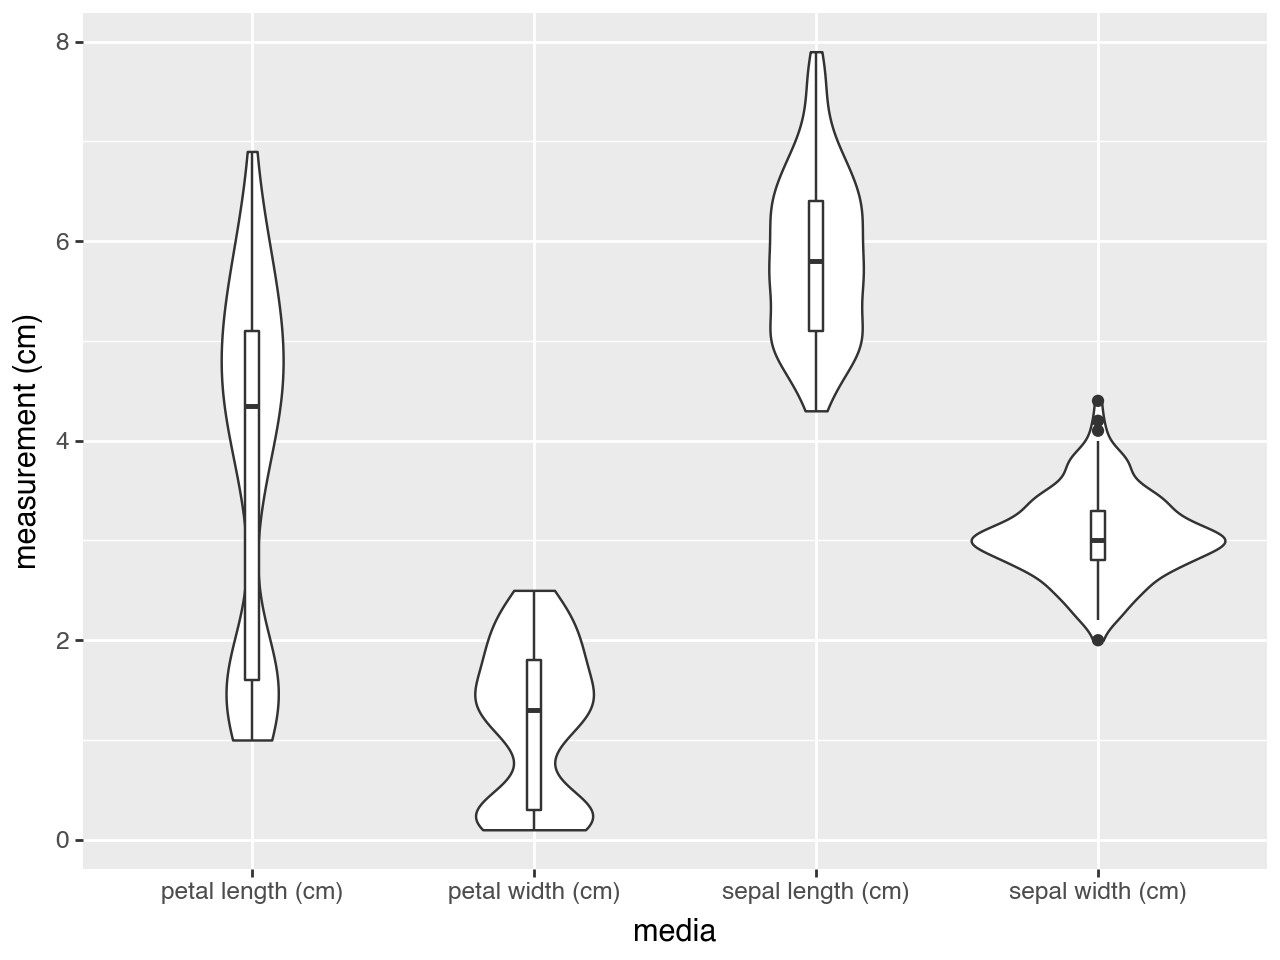

In [53]:
(
    ggplot(iris_dist, aes(x = 'media', y = 'measurement (cm)')) +
    geom_violin() + 
    geom_boxplot(width = 0.05) 
)

## geom_qq - QQ_plot

       

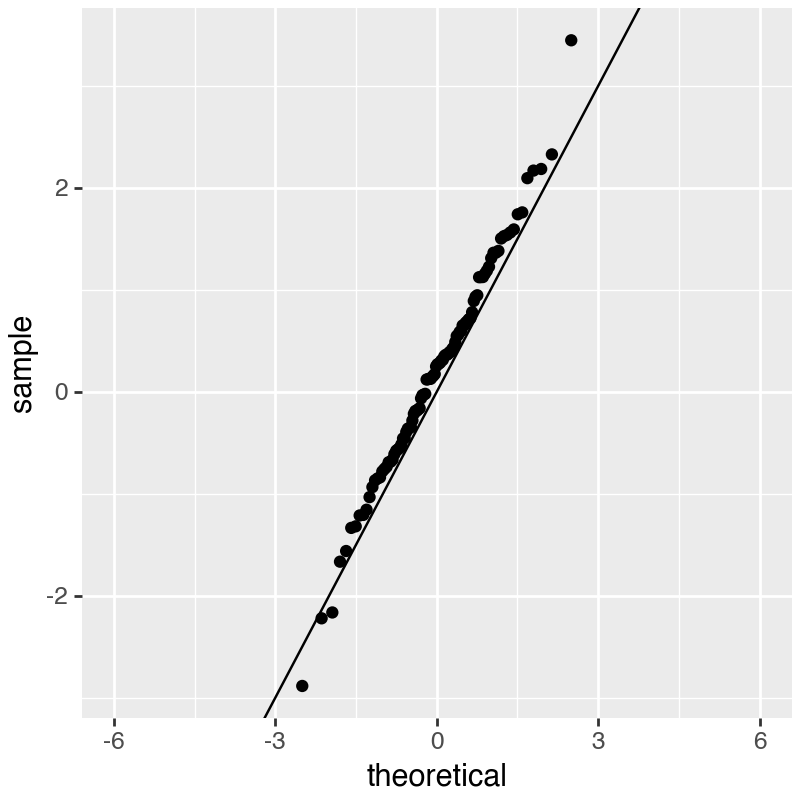

In [57]:
np.random.seed(525)

points = np.random.normal(loc = 0, scale = 1, size = 100)
dt = pd.DataFrame({'points':points})

(
    ggplot(dt, aes(sample = 'points')) +
    geom_qq() + 
    geom_abline(slope = 1, intercept = 0) + 
    xlim(-6,6) + 
    theme(figure_size=(4,4))
)

## geom_bin_2d()

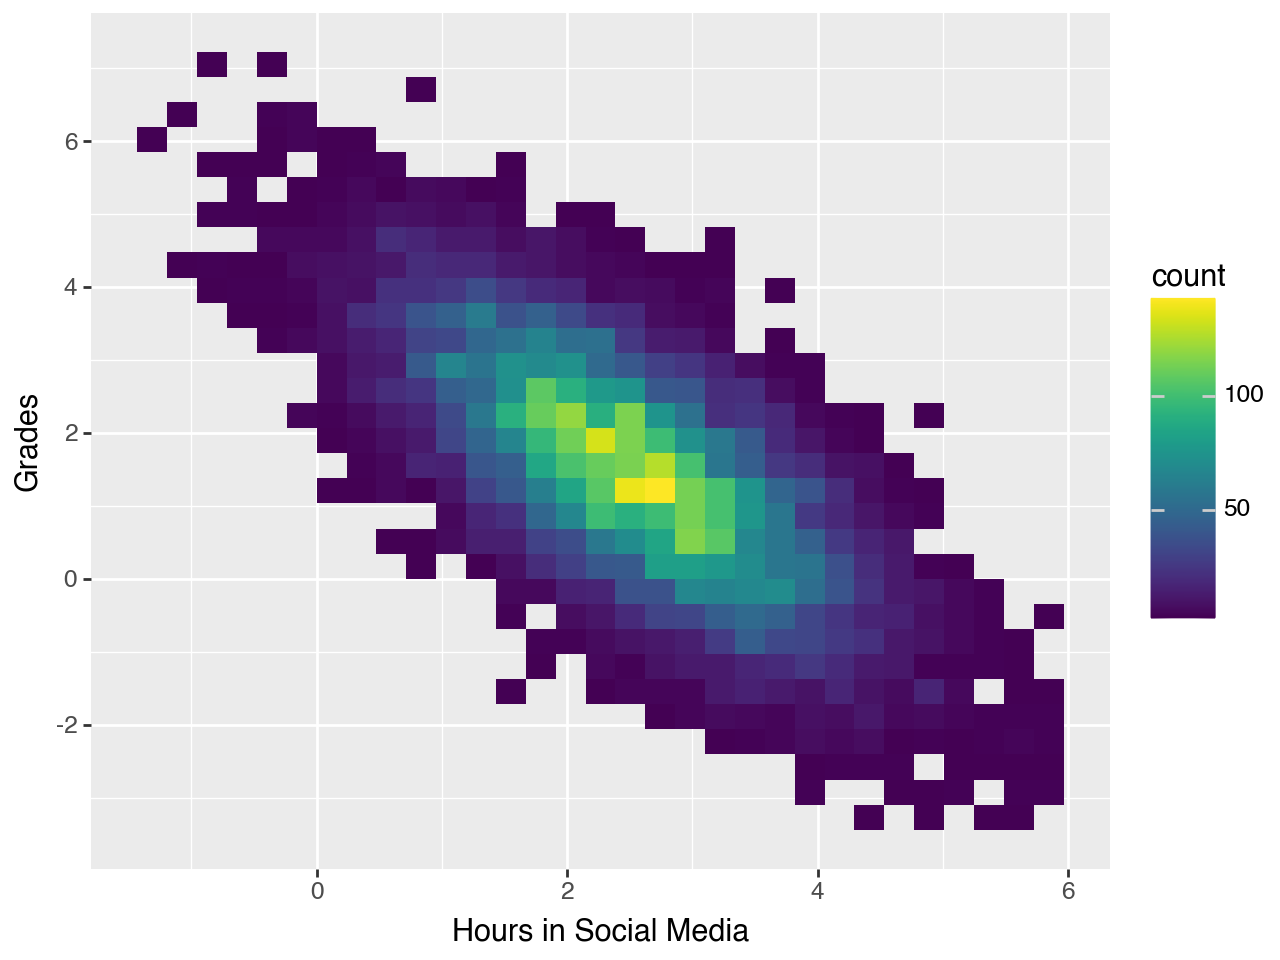

In [59]:
hours_in_social_media = np.random.normal(loc = 2.5, scale = 1, size = 10000)
grades = 4 - hours_in_social_media + np.random.normal(loc = 0, scale = 1, size = 10000)

grade_media = pd.DataFrame({
    'grades' : grades,
    'media_h': hours_in_social_media
})

(
    ggplot(grade_media, aes('media_h', 'grades')) +
    geom_bin_2d(bins = 30) +  
    labs(y = 'Grades', x = 'Hours in Social Media')
)

----------

# Correlation

pandas.DataFrame.corr()

In [58]:
anscombe = sns.load_dataset('anscombe')
anscombe.head()

correlations = anscombe.groupby('dataset').apply(
    lambda group: pd.Series({'correlation': group['x'].corr(group['y'])})
).reset_index()
correlations

/var/folders/nn/rd9y9hfx7qz4tk9cjwqs2xrh0000gn/T/ipykernel_92911/3703761813.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


,dataset,correlation
0,I,0.816421
1,II,0.816237
2,III,0.816287
3,IV,0.816521


-----

# cut 

In [61]:
hours_in_social_media = np.random.normal(loc = 2.5, scale = 1, size = 10000)
grades = 4 - hours_in_social_media + np.random.normal(loc = 0, scale = 1, size = 10000)

grade_media = pd.DataFrame({
    'grades' : grades,
    'media_h': hours_in_social_media
})

grade_media['bins'] = pd.cut(grade_media['media_h'], bins=6)

grade_media.head()

,grades,media_h,bins
0,1.241902,2.126250,"(1.784, 3.248]"
1,2.975645,1.675989,"(0.32, 1.784]"
2,-0.264601,3.999108,"(3.248, 4.712]"
3,1.535780,2.683965,"(1.784, 3.248]"
4,1.235296,1.484770,"(0.32, 1.784]"


--------

# PCA

Dont forget preprocessing !!! 

In [69]:
import sklearn

iris = sklearn.datasets.load_iris(as_frame= True)
iris_df = iris['frame']
iris_df['target'] = ['setosa' if s==0 else 'versicolor' if s==1 else 'virginica' \
for s in iris['target']]

iris_df = iris_df[iris_df['target'] == 'setosa']
iris_df.drop(columns = 'target', inplace= True)
iris_df.head()

/var/folders/nn/rd9y9hfx7qz4tk9cjwqs2xrh0000gn/T/ipykernel_92911/2967219013.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [71]:
# Standard Scale
X = sklearn.preprocessing.StandardScaler().fit_transform(iris_df) 

pca_res = sklearn.decomposition.PCA().fit(X)

## Component Analysis

In [72]:
sum_df = pd.DataFrame({
    'Variance': pca_res.explained_variance_,
    'Proportion of Variance': pca_res.explained_variance_ratio_,
    'Cumulative Proportion': np.cumsum(pca_res.explained_variance_ratio_)
}, index=[f'PC{i+1}' for i in range(pca_res.n_components_)])
sum_df

,Variance,Proportion of Variance,Cumulative Proportion
PC1,2.100551,0.514635,0.514635
PC2,1.043039,0.255545,0.770180
PC3,0.681449,0.166955,0.937135
PC4,0.256593,0.062865,1.000000


## Project Data

In [75]:
scores_df = pd.DataFrame(pca_res.transform(X), columns = [f'PC{i+1}' for i in range(len(pca_res.components_))])
scores_df.head()

,PC1,PC2,PC3,PC4
0,-0.039815,-0.642576,-0.097234,0.099546
1,-1.153210,0.136821,-0.057675,0.604718
2,-1.411224,-0.270827,0.374379,-0.124312
3,-1.301071,0.672035,-0.393782,-0.248046
4,-0.059633,-0.664054,-0.078121,-0.290225


-----
------

# Errors

        iris_dist_1['side'] = iris_dist['media'].str.split()[0]

To get the first index of array you should again .str[0]

In [55]:
iris_dist_1 = iris_dist.copy()
iris_dist_1['side'] = iris_dist['media'].str.split().str[0]

------

    df.loc[ df['point']== 'X1', ['x','y']] = new_centroids.loc['X1'].values

dont forget to put values otherwise it makes the x and y columns NaN

--------

    row_col = row_ann.map(lambda x: color_mapping[x])

USE `map` not `apply`  

-------

------
# Good Questions

1. What could make k-means clustering fail?

    1. When clusters are isotropically distributed.
    
    2. When clusters have similar sizes.

    3. When data are not normalized.

    4. When clusters have similar variances.

Answer: 3. If the input variables are on very different scales, the Euclidean distance will give more
weight to variables with larger variances. Hence, standardization, one of the two steps of normalization,
is typically needed.

-----

## Rand Index

$$

\begin{aligned}
a &:\ \text{number of pairs of elements of } S \text{ that are in the same set in } X \text{ and } Y \\
b &:\ \text{number of pairs of elements of } S \text{ that are in different sets in } X \text{ and } Y \\
\binom{n}{2} &:\ \text{total number of pairs of elements of } S
\end{aligned}
$$

$$
R = \frac{a + b}{\binom{n}{2}}.
$$

-----

# Linkage Rules

* `Complete`: The dissimilarity between cluster A and cluster B is the largest dissimilarity between any element of A and any element of B.

* `Single`: The dissimilarity between cluster A and cluster B is the smallest dissimilarity between any element of A and any element of B. Single linkage can result in extended, trailing clusters in which single observations are fused one-at-a-time.

* `Average`: The dissimilarity between cluster A and cluster B is the average dissimilarity between any element of A and any element of B.

* `Centroid`: The dissimilarity between cluster A and cluster B is the dissimilarity between the centroids (mean vector) of A and B. Centroid linkage can result in undesirable inversions.

-------

Exercise 5 look !!! 

-----